# Challenge: Image Classification with Deep Learning

##  Objective
Build and compare different deep learning models for image classification on a standard dataset.

---

##  Dataset Selection & Download
For this challenge, we are utilizing the **Fashion-MNIST** dataset, a direct drop-in replacement for the classic MNIST dataset featuring 70,000 grayscale images of 10 fashion categories.

* **Official Repository:** [Fashion-MNIST on GitHub](https://github.com/zalandoresearch/fashion-mnist)
* **Direct Download Source:** [Fashion-MNIST Dataset on Kaggle](https://www.kaggle.com/datasets/zalando-research/fashion-mnist)

---

##  Tasks

### 1. Dataset Selection
Choose a standard image classification dataset (e.g., CIFAR-10, MNIST, or Fashion-MNIST).

### 2. Data Preprocessing
Prepare the dataset for training, including image resizing, normalization, and data augmentation techniques.

### 3. Model Architecture
Experiment with different convolutional neural network (CNN) architectures (e.g., LeNet, AlexNet, VGG, ResNet).

### 4. Hyperparameter Tuning
Optimize model performance by tuning hyperparameters (learning rate, batch size, number of epochs, etc.).

### 5. Model Training
Train the selected models on the prepared dataset.

### 6. Model Evaluation
Use appropriate metrics (accuracy, precision, recall, F1-score) to evaluate model performance.

### 7. Model Comparison
Compare the performance of different models and analyze their strengths and weaknesses.

### 8. Visualization
Create visualizations to understand the learned features (e.g., activation maps, filters).

---

## 🚀 Additional Challenges
* **Transfer Learning:** Utilize pre-trained models (e.g., from ImageNet) and fine-tune them for the target dataset.
* **Model Optimization:** Explore techniques like model pruning, quantization, and knowledge distillation to optimize model size and speed.
* **Adversarial Attacks:** Investigate the vulnerability of your models to adversarial attacks.

---

## 📊 Evaluation Criteria
* Model accuracy
* Training and inference time
* Model complexity
* Ability to explain the rationale behind predictions

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/organizations/zalando-research/fashionmnist/train-images-idx3-ubyte


In [3]:
from subprocess import check_output
print(check_output(["ls", "../input"]).decode("utf8"))
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard
num_classes = 10
epochs = 20

datasets



2026-06-30 18:23:13.271625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782843793.485836      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782843793.543237      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782843794.039377      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782843794.039426      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782843794.039429      58 computation_placer.cc:177] computation placer alr

In [6]:
train_df = pd.read_csv('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv', sep=',')
test_df = pd.read_csv('/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv', sep=',')

In [7]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Now it is observed that the first column is the label data and because it has 10 classes so it is going to have from 0 to 9.The remaining columns are the actual pixel data.Here as you can see there are about 784 columns that contain pixel data. Here each row is a different image representation in the form pixel data.

Now let us split the train data into x and y arrays where x represents the image data and y represents the labels.

To do that we need to convert the dataframes into numpy arrays of float32 type which is the acceptable form for tensorflow and keras.

In [9]:
train_data = np.array(train_df, dtype = 'float32')

In [10]:
test_data = np.array(test_df, dtype='float32')

In [11]:
x_train = train_data[:,1:]/255

y_train = train_data[:,0]

x_test= test_data[:,1:]/255

y_test=test_data[:,0]

In [12]:
x_train,x_validate,y_train,y_validate = train_test_split(x_train,y_train,test_size = 0.2,random_state = 12345)

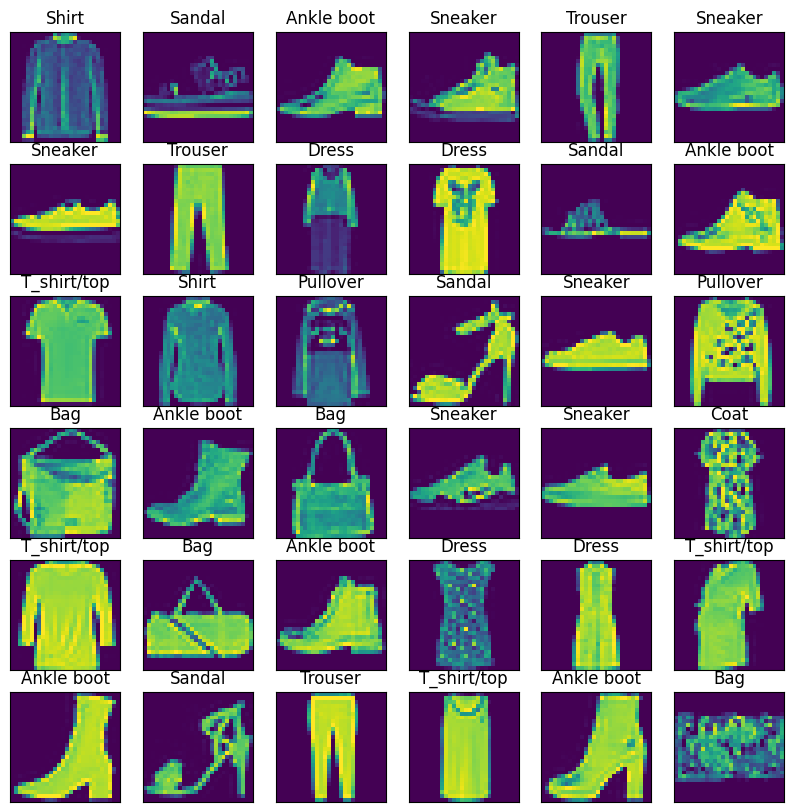

In [13]:
class_names = ['T_shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(10, 10))
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i].reshape((28,28)))
    label_index = int(y_train[i])
    plt.title(class_names[label_index])
plt.show()

In [14]:
image_rows = 28
image_cols = 28
batch_size = 4096
image_shape = (image_rows,image_cols,1) 

In [15]:
x_train = x_train.reshape(x_train.shape[0],*image_shape)
x_test = x_test.reshape(x_test.shape[0],*image_shape)
x_validate = x_validate.reshape(x_validate.shape[0],*image_shape)

In [16]:
model_A= Sequential([
    Conv2D(filters=32,kernel_size=3,activation='relu',input_shape = image_shape),
    MaxPooling2D(pool_size=2) ,# down sampling the output instead of 28*28 it is 14*14
    Dropout(0.2),
    Flatten(), # flatten out the layers
    Dense(32,activation='relu'),
    Dense(10,activation = 'softmax')
    
])

I0000 00:00:1782844099.476481      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782844099.482737      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [17]:
from keras.optimizers import Adam

model_A.compile(
    loss='sparse_categorical_crossentropy', 
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [19]:
history_A = model_A.fit(
    x_train,
    y_train,
    batch_size=4096,
    epochs=75,
    verbose=1,
    validation_data=(x_validate,y_validate),
)

Epoch 1/75


I0000 00:00:1782844129.960460     168 service.cc:152] XLA service 0x7b9b780021a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782844129.960496     168 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782844129.960500     168 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782844130.254929     168 cuda_dnn.cc:529] Loaded cuDNN version 91002


 5/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2470 - loss: 2.2097

I0000 00:00:1782844133.852296     168 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 384ms/step - accuracy: 0.4482 - loss: 1.7920 - val_accuracy: 0.6107 - val_loss: 1.2572
Epoch 2/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6959 - loss: 0.9827 - val_accuracy: 0.7484 - val_loss: 0.7404
Epoch 3/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7659 - loss: 0.6761 - val_accuracy: 0.7788 - val_loss: 0.6106
Epoch 4/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7939 - loss: 0.5842 - val_accuracy: 0.8062 - val_loss: 0.5496
Epoch 5/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8128 - loss: 0.5331 - val_accuracy: 0.8243 - val_loss: 0.5051
Epoch 6/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8277 - loss: 0.4985 - val_accuracy: 0.8315 - val_loss: 0.4816
Epoch 7/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8350 - loss: 0.4756 - val_accuracy: 0.8407 - val_loss: 0.4614
Epoch 8/75
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8408 - loss: 0.4561 - val_accuracy: 0.8461 - val_loss: 0

In [27]:
# Define Model B
model_B = Sequential([
    Conv2D(32, kernel_size=3, activation='relu', input_shape=image_shape),
    MaxPooling2D(pool_size=2),
    Conv2D(64, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_B.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train Model B safely
history_B = model_B.fit(x_train, y_train, validation_data=(x_validate, y_validate), epochs=75, batch_size=64)

Epoch 1/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8093 - loss: 0.5292 - val_accuracy: 0.8607 - val_loss: 0.3830
Epoch 2/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8733 - loss: 0.3535 - val_accuracy: 0.8784 - val_loss: 0.3313
Epoch 3/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8886 - loss: 0.3110 - val_accuracy: 0.8804 - val_loss: 0.3278
Epoch 4/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8982 - loss: 0.2818 - val_accuracy: 0.8940 - val_loss: 0.2870
Epoch 5/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9069 - loss: 0.2574 - val_accuracy: 0.9007 - val_loss: 0.2716
Epoch 6/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9138 - loss: 0.2368 - val_accuracy: 0.9043 - val_loss: 0.2593
Epoch 7/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9211 - loss: 0.2169 - val_accuracy: 0.9057 - val_loss: 0.2502
Epoch 8/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9269 - loss: 0.2030 - val_accuracy: 0.

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Dense, Dropout, Resizing
from tensorflow.keras.applications import MobileNetV2

# 1. Initialize the base model with the minimum valid dimension (32, 32, 3)
base_model = MobileNetV2(
    input_shape=(32, 32, 3), # Changed from 28 to 32 to fix the ValueError
    include_top=False, 
    weights='imagenet'
)

# Freeze the pre-trained weights so we don't mess up ImageNet features
base_model.trainable = False

# 2. Build the final model architecture
model_TL = Sequential([
    # Step A: Dynamically resize your 28x28 grayscale images up to 32x32
    Resizing(32, 32, input_shape=(28, 28, 1)),
    
    # Step B: Standardize the single channel into 3 identical channels for MobileNet
    Conv2D(3, kernel_size=1, padding='same'),
    
    # Step C: The pre-trained network base
    base_model,
    
    # Step D: Regularization and output head
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(10, activation='softmax')
], name="Transfer_Learning_MobileNetV2")

# 3. Compile and fit
model_TL.compile(
    loss='sparse_categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

history_TL = model_TL.fit(
    x_train, y_train, 
    validation_data=(x_validate, y_validate), 
    epochs=75, 
    batch_size=64
)

Epoch 1/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.4532 - loss: 1.7023 - val_accuracy: 0.5990 - val_loss: 1.3630
Epoch 2/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5336 - loss: 1.3874 - val_accuracy: 0.6212 - val_loss: 1.2056
Epoch 3/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5498 - loss: 1.3084 - val_accuracy: 0.6360 - val_loss: 1.1344
Epoch 4/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5616 - loss: 1.2687 - val_accuracy: 0.6396 - val_loss: 1.0834
Epoch 5/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5727 - loss: 1.2280 - val_accuracy: 0.6513 - val_loss: 1.0478
Epoch 6/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5822 - loss: 1.1997 - val_accuracy: 0.6574 - val_loss: 1.0272
Epoch 7/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5855 - loss: 1.1860 - val_accuracy: 0.6572 - val_loss: 1.0154
Epoch 8/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5871 - loss: 1.1786 - val_accuracy: 

In [41]:
import tensorflow as tf

# 1. Unfreeze the base model so its deep weights can adapt
base_model.trainable = True

# 2. Freeze the early layers, leave the last 20 layers open for adaptation
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 3. Re-compile with an extremely low learning rate (vital for fine-tuning!)
model_TL.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 100x smaller than normal
    metrics=['accuracy']
)

# 4. Set up Early Stopping so it stops automatically when it hits peak performance
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 5. Fit the model cleanly without loops
history_TL = model_TL.fit(
    x_train, y_train,
    validation_data=(x_validate, y_validate),
    epochs=75, # Higher epoch limit since early_stop will catch it if it overfits
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.8899 - loss: 0.3036 - val_accuracy: 0.8622 - val_loss: 0.3937
Epoch 2/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8879 - loss: 0.3062 - val_accuracy: 0.8621 - val_loss: 0.3957
Epoch 3/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8904 - loss: 0.3011 - val_accuracy: 0.8642 - val_loss: 0.3931
Epoch 4/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8937 - loss: 0.2913 - val_accuracy: 0.8656 - val_loss: 0.3934
Epoch 5/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8918 - loss: 0.2918 - val_accuracy: 0.8669 - val_loss: 0.3926
Epoch 6/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8953 - loss: 0.2853 - val_accuracy: 0.8648 - val_loss: 0.3939
Epoch 7/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8956 - loss: 0.2836 - val_accuracy: 0.8657 - val_loss: 0.3923
Epoch 8/75
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8977 - loss: 0.2782 - val_accuracy: 

In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def get_model_metrics(model_name, model, x_test_data, y_true_labels):
    # Get predictions
    raw_preds = model.predict(x_test_data, verbose=0)
    predicted_classes = np.argmax(raw_preds, axis=1)
    
    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_true_labels, predicted_classes, average='macro')
    accuracy = accuracy_score(y_true_labels, predicted_classes)
    
    # Return as a simple dictionary row
    return {
        "Model Name": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision (Macro)": round(precision, 4),
        "Recall (Macro)": round(recall, 4),
        "F1-Score (Macro)": round(f1, 4)
    }

# Instantly build your paper table by passing your trained models directly!
row_A = get_model_metrics("Basic CNN", model_A, x_test, y_test)
row_B = get_model_metrics("Deeper CNN", model_B, x_test, y_test)

# Grabs the metrics for the transfer learning model
row_TL = get_model_metrics("Transfer Learning (MobileNetV2)", model_TL, x_test, y_test)

# Append it alongside your previous model rows directly into the table!
comparison_table = pd.DataFrame([row_A, row_B, row_TL])

print("\n--- Updated Performance Comparison ---")
display(comparison_table)

2026-06-30 19:29:57.497726: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 19:29:57.655483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 19:29:57.791715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



--- Updated Performance Comparison ---


,Model Name,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Basic CNN,0.9119,0.9120,0.9119,0.9115
1,Deeper CNN,0.9089,0.9086,0.9089,0.9082
2,Transfer Learning (MobileNetV2),0.6708,0.6656,0.6708,0.6658


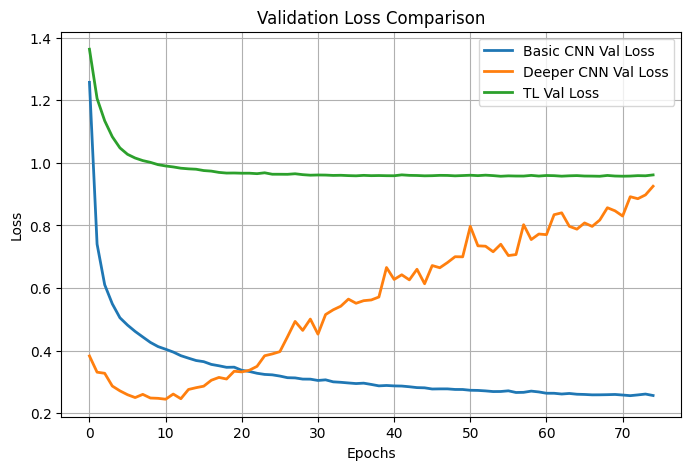

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot lines directly using your history variables
plt.plot(history_A.history['val_loss'], label="Basic CNN Val Loss", linewidth=2)
plt.plot(history_B.history['val_loss'], label="Deeper CNN Val Loss", linewidth=2)
plt.plot(history_TL.history['val_loss'], label="TL Val Loss", linewidth=2)


plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

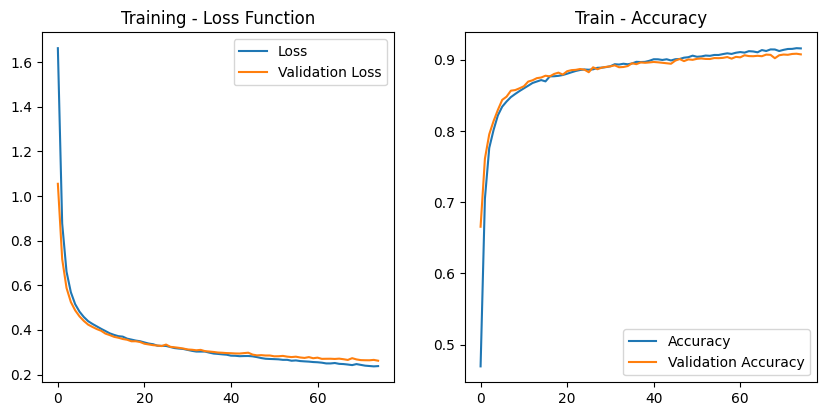

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

# 1. Loss Subplot
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training - Loss Function')

# 2. Accuracy Subplot
plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') # Fixed 'val_acc' to 'val_accuracy'
plt.legend()
plt.title('Train - Accuracy')

plt.show() # Added to cleanly display the plots

In [17]:
score = cnn_model.evaluate(x_test,y_test,verbose=0)
print('Test Loss : {:.4f}'.format(score[0]))
print('Test Accuracy : {:.4f}'.format(score[1]))


Test Loss : 0.2594
Test Accuracy : 0.9109


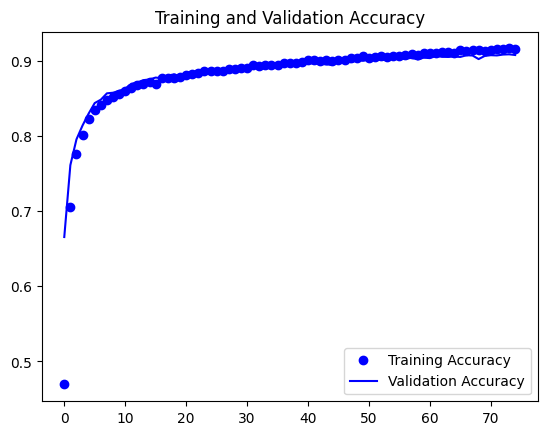

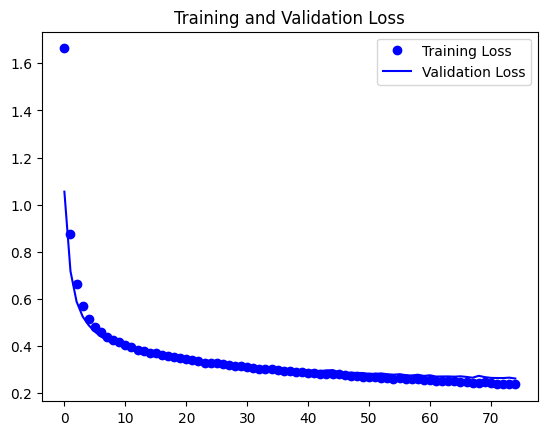

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(accuracy))

# 1. Plot Accuracy
plt.plot(epochs, accuracy, 'bo', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# 2. Plot Loss in a separate figure
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [28]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Get the raw probability predictions for the test data
probabilities = cnn_model.predict(x_test)

# 2. Extract the class with the highest probability for each sample
predicted_classes = np.argmax(probabilities, axis=1)

# Get the true labels from your dataframe
y_true = test_df.iloc[:, 0]

# Get the indices of correct and incorrect predictions to plot later
correct = np.nonzero(predicted_classes == y_true)[0]
incorrect = np.nonzero(predicted_classes != y_true)[0]

# Generate and print the classification report
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(y_true, predicted_classes, target_names=target_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

     Class 0       0.87      0.84      0.85      1000
     Class 1       0.98      0.98      0.98      1000
     Class 2       0.89      0.85      0.87      1000
     Class 3       0.89      0.94      0.92      1000
     Class 4       0.86      0.88      0.87      1000
     Class 5       0.98      0.97      0.97      1000
     Class 6       0.76      0.75      0.75      1000
     Class 7       0.95      0.95      0.95      1000
     Class 8       0.98      0.97      0.98      1000
     Class 9       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
--- Classification Report ---
              precision    recall  f1-score   support

 T_shirt/top       0.87      0.84      0.85      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.89      0.85      0.87      1000
       Dress       0.89      0.94      0.92      1000
        Coat       0.86      0.88      0.87      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.76      0.75      0.75      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

--- Generating Confusion Matrix ---


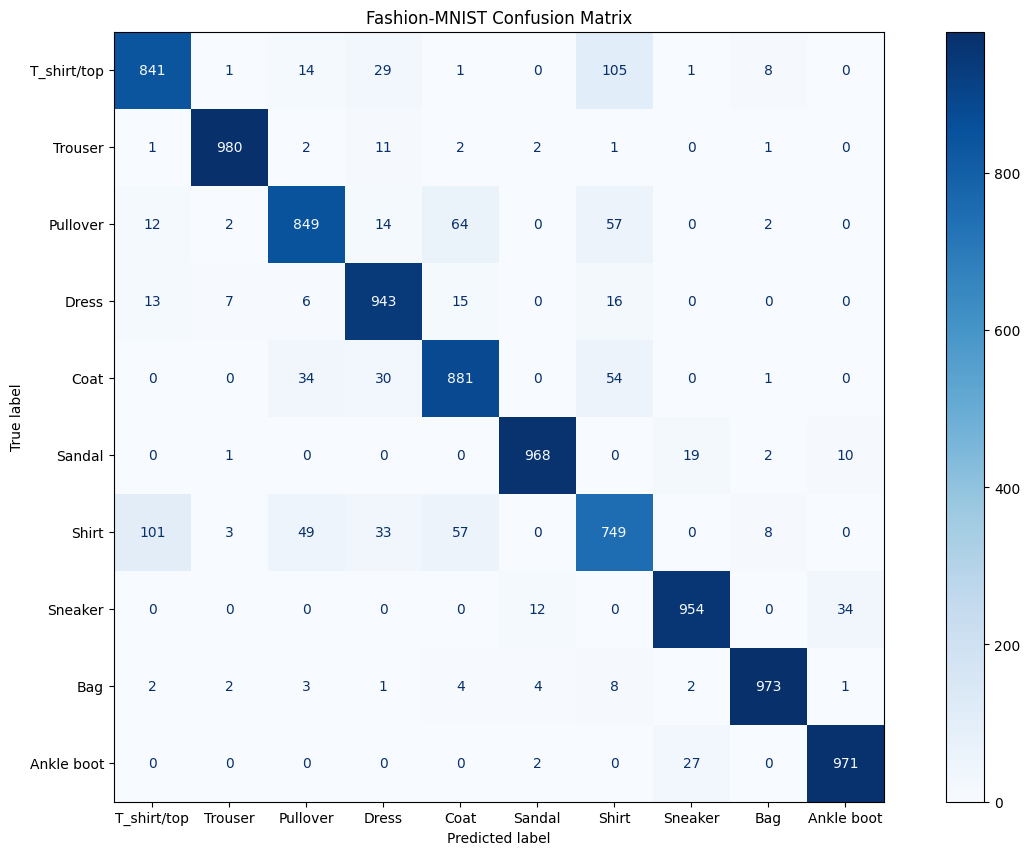

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. FIX: Get predictions correctly (predict_classes is deprecated)
predictions = cnn_model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=1) # Extracts the class with highest probability

# 2. Get the true labels
y_true = test_df.iloc[:, 0].values # Added .values to handle matching safely

# 3. Get the indices for correct and incorrect matches
correct = np.nonzero(predicted_classes == y_test)[0]
incorrect = np.nonzero(predicted_classes != y_test)[0]

# 4. Print the Classification Report
num_classes = 10
target_names = [f"Class {i}" for i in range(num_classes)]
print("--- Classification Report ---")
print(classification_report(y_test, predicted_classes, target_names=class_names))

# ==============================================================================
# 5. ADDING THE CONFUSION MATRIX
# ==============================================================================
print("--- Generating Confusion Matrix ---")

# Compute the confusion matrix values
cm = confusion_matrix(y_test, predicted_classes)

# Create the visual display grid
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot it beautifully using matplotlib
fig, ax = plt.subplots(figsize=(16, 10))
disp.plot(ax=ax, cmap='Blues', values_format='d') # 'd' displays numbers as regular integers
plt.title('Fashion-MNIST Confusion Matrix')
plt.show()

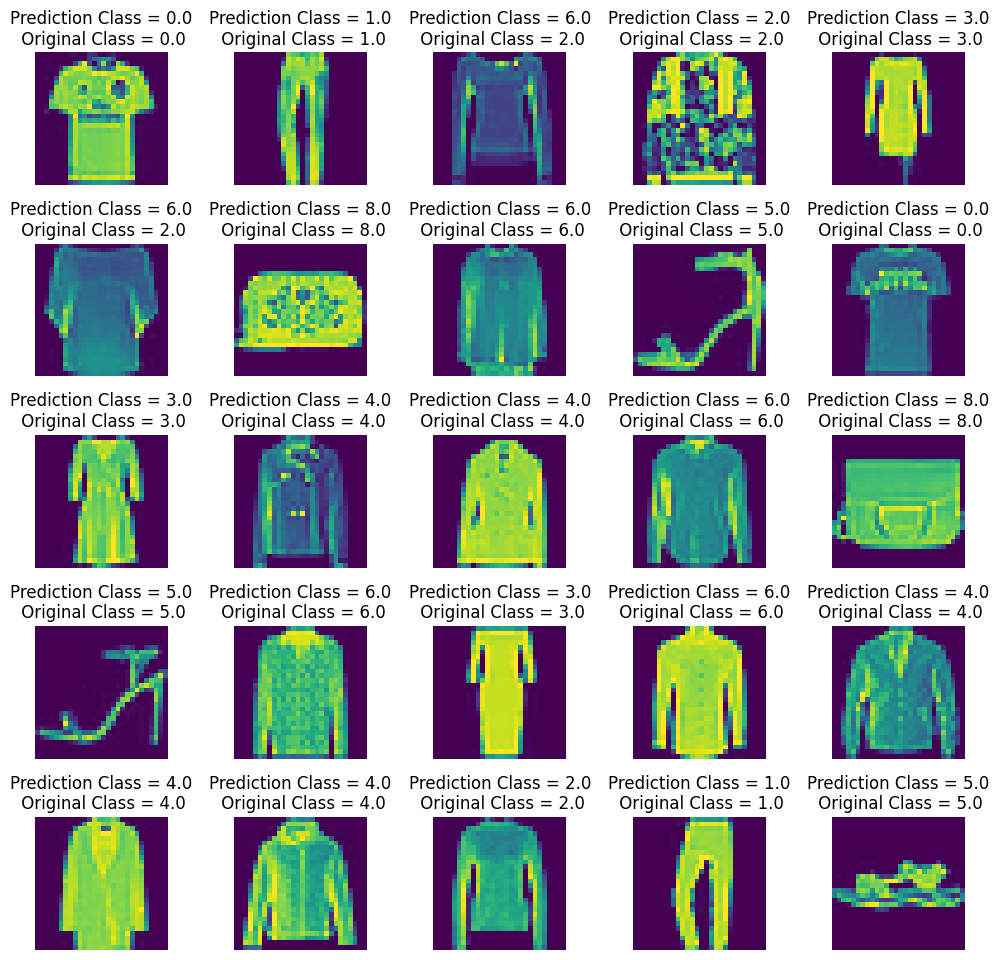

In [34]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):  
    axes[i].imshow(x_test[i].reshape(28,28))
    axes[i].set_title(f"Prediction Class = {predicted_classes[i]:0.1f}\n Original Class = {y_test[i]:0.1f}")
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)